<a href="https://colab.research.google.com/github/1vxw/maze_gen/blob/main/mazeGen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

State Explored:  235 Seed:  0
Found solution, Path length: 158
███████████████████████████████████████
█S....█    ...█ █    .....█ █         █
█████.█ ███.█.█ █ ███.███.█ █ █████ ███
█.....█ █...█.█   █...█...█   █   █   █
█.███████.███.███ █.███.███ █████ ███ █
█.........█ █...█ █...█...█         █ █
███████████ ███.█████.███.█████████ █ █
█   █     █  G█.......█ █...█ █     █ █
█ █ █ █ ███ █.█████████ ███.█ █ █████ █
█ █ █ █   █ █.█.....  █.....█   █   █ █
███ █ ███ █ █.█.███.█ █.█████ ███ █ █ █
█   █ █ █   █...█...█ █.█   █     █ █ █
█ ███ █ █████████.███ █.███ █ ███████ █
█   █     █ █.....█   █...█   █...█...█
█ █ █████ █ █.███████████.█████.█.█.█.█
█ █     █   █.█.......  █.......█...█.█
█ ███ █████ █.█.█████.███████████████.█
█   █       █...    █.................█
███████████████████████████████████████
State Explored:  141 Seed:  1
Found solution, Path length: 114
███████████████████████████████████████
█S█       █      ...█  .....█         █
█.█████ █ █ █████.█.███.███.█ ███ 

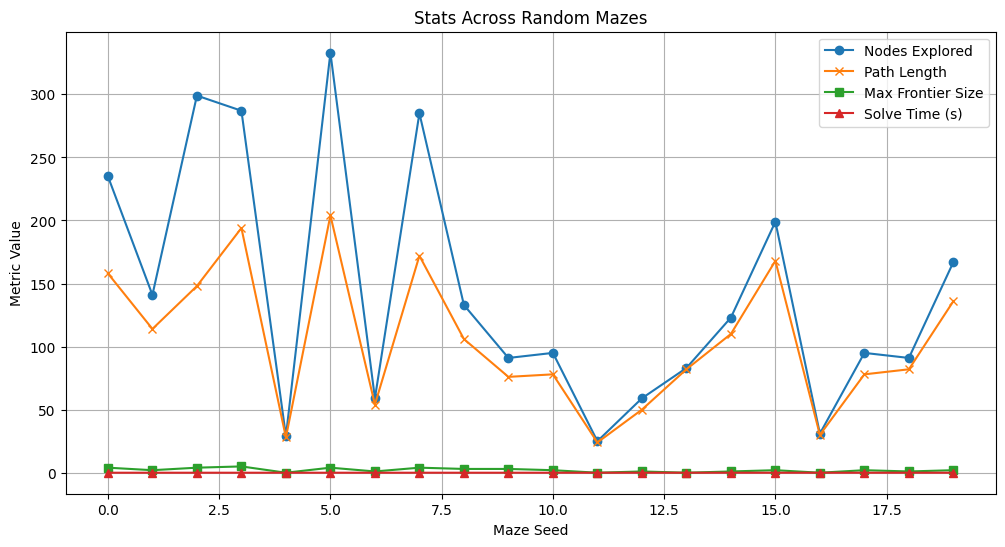

In [41]:
import random
import time
import heapq
import matplotlib.pyplot as plt

class Node():
    def __init__(self, s, p, a, g=0, h=0):
        self.state = s
        self.parent = p
        self.action = a
        self.g = g
        self.h = h
        self.f = g + h

class PriorityFrontier():
    def __init__(self):
        self.frontier = []
        self.counter = 0

    def add(self, node, priority):
        heapq.heappush(self.frontier, (priority, self.counter, node))
        self.counter += 1

    def empty(self):
        return len(self.frontier) == 0

    def remove(self):
        if self.empty():
            raise Exception("empty frontier")
        return heapq.heappop(self.frontier)[2]

    def contain_state(self, state):
        return any(node.state == state for _, _, node in self.frontier)

class GenMaze():
    MARK = '@'
    EMPTY = ' '
    UP, DOWN, LEFT, RIGHT = 'u','d','l','r'
    WALL = chr(9608)

    def __init__(self, W, H, SEED, x, y):
        self.width = W
        self.height = H
        self.seed = SEED
        self.x = x
        self.y = y

        random.seed(self.seed)
        self.visited = [(x,y)]

        self.maze = [[self.WALL for _ in range(self.height)] for _ in range(self.width)]
        self.maze[x][y] = self.EMPTY

        self.num_explored = 0
        self.start = (self.x, self.y)
        self.explored = set()
        self.solution = None
        self.max_frontier = 0

        self.goal = None

    def printMaze(self, maze, show_start=True, show_goal=True):
        for y in range(self.height):
            for x in range(self.width):
                if show_start and (x, y) == self.start:
                    print('S', end="")
                elif show_goal and (x, y) == self.goal:
                    print('G', end="")
                else:
                    print(maze[x][y], end="")
            print()

    def getMaze(self):
        return self.maze

    def getX(self):
        return self.x

    def getY(self):
        return self.y

    def visit(self, x, y):
        self.maze[x][y] = self.EMPTY

        while True:
            unvN = []

            if y > 1 and (x, y-2) not in self.visited:
                unvN.append(self.UP)
            if y < self.height - 2 and (x, y+2) not in self.visited:
                unvN.append(self.DOWN)
            if x > 1 and (x - 2, y) not in self.visited:
                unvN.append(self.LEFT)
            if x < self.width - 2 and (x + 2,y) not in self.visited:
                unvN.append(self.RIGHT)

            if len(unvN) == 0:
                return
            else:
                nextIntersection = random.choice(unvN)
                match nextIntersection:
                    case self.UP:
                        nextX = x
                        nextY = y - 2
                        self.maze[x][y-1] = self.EMPTY
                    case self.DOWN:
                        nextX = x
                        nextY = y + 2
                        self.maze[x][y+1] = self.EMPTY
                    case self.LEFT:
                        nextX = x - 2
                        nextY = y
                        self.maze[x-1][y] = self.EMPTY
                    case self.RIGHT:
                        nextX = x + 2
                        nextY = y
                        self.maze[x+1][y] = self.EMPTY
                self.visited.append((nextX, nextY))
                self.visit(nextX, nextY)

    def neighbors(self, state):
        curr_x, curr_y = state
        candidates = []

        if curr_y > 0 and self.maze[curr_x][curr_y - 1] != self.WALL:
            candidates.append((self.UP, (curr_x, curr_y - 1)))
        if curr_y < self.height - 1 and self.maze[curr_x][curr_y + 1] != self.WALL:
            candidates.append((self.DOWN, (curr_x, curr_y + 1)))
        if curr_x > 0 and self.maze[curr_x - 1][curr_y] != self.WALL:
            candidates.append((self.LEFT, (curr_x - 1, curr_y)))
        if curr_x < self.width - 1 and self.maze[curr_x + 1][curr_y] != self.WALL:
            candidates.append((self.RIGHT, (curr_x + 1, curr_y)))

        return candidates

    def heuristic(self, state):
        x1, y1 = state
        x2, y2 = self.goal
        return abs(x1 - x2) + abs(y1 - y2)

    def random_goal(self):
        self.goal = random.choice([cell for cell in self.visited if cell != self.start])

    def solve(self):
        self.num_explored = 0
        self.explored = set()
        self.max_frontier = 0

        start_node = Node(self.start, None, None, g=0, h=self.heuristic(self.start))
        frontier = PriorityFrontier()
        frontier.add(start_node, start_node.f)

        while True:
            if frontier.empty():
                raise Exception("No solution")

            node = frontier.remove()
            self.num_explored += 1
            self.max_frontier = max(self.max_frontier, len(frontier.frontier))
            self.explored.add(node.state)

            if node.state == self.goal:
                actions = []
                cells = []
                while node.parent is not None:
                    actions.append(node.action)
                    cells.append(node.state)
                    node = node.parent
                actions.reverse()
                cells.reverse()
                self.solution = (actions, cells)
                return

            for action, state in self.neighbors(node.state):
                if state not in self.explored and not frontier.contain_state(state):
                    g = node.g + 1
                    h = self.heuristic(state)
                    child = Node(state, node, action, g, h)
                    frontier.add(child, child.f)

    def printSolution(self):
        if self.solution:
            actions, cells = self.solution
            print(f"Found solution, Path length: {len(actions)}")
            maze_copy = [row[:] for row in self.getMaze()]
            for cell in cells:
                if cell != self.start and cell != self.goal:
                    x, y = cell
                    if 0 <= x < len(maze_copy) and 0 <= y < len(maze_copy[0]):
                        maze_copy[x][y] = '.'

            for y in range(self.height):
                for x in range(self.width):
                    if (x, y) == self.start:
                        print('S', end="")
                    elif (x, y) == self.goal:
                        print('G', end="")
                    else:
                        print(maze_copy[x][y], end="")
                print()
        else:
            print("No solution found")

width, height = 39, 19
start_x, start_y = 1, 1

results = []
num_runs = 20

for seed in range(num_runs):
    maze = GenMaze(width, height, seed, start_x, start_y)
    maze.visit(maze.getX(), maze.getY())

    maze.random_goal()
    start_time = time.time()

    maze.solve()

    end_time = time.time()
    print("State Explored: ",maze.num_explored, "Seed: ",seed)
    maze.printSolution()

    actions, cells = maze.solution
    results.append({
        "seed": seed,
        "num_explored": maze.num_explored,
        "path_length": len(actions),
        "max_frontier": maze.max_frontier,
        "solve_time": end_time - start_time
    })

seeds = [r['seed'] for r in results]
num_explored = [r['num_explored'] for r in results]
path_length = [r['path_length'] for r in results]
max_frontier = [r['max_frontier'] for r in results]
solve_time = [r['solve_time'] for r in results]

plt.figure(figsize=(12,6))
plt.plot(seeds, num_explored, marker='o', label='Nodes Explored')
plt.plot(seeds, path_length, marker='x', label='Path Length')
plt.plot(seeds, max_frontier, marker='s', label='Max Frontier Size')
plt.plot(seeds, solve_time, marker='^', label='Solve Time (s)')
plt.xlabel("Maze Seed")
plt.ylabel("Metric Value")
plt.title("Stats Across Random Mazes")
plt.legend()
plt.grid(True)
plt.show()